# Pandas 学习笔记

## 核心目标
- 掌握 Pandas 基础操作
- 学习数据清洗和特征工程
- 实践社招必备的数据处理技能
- 涵盖官方文档中的所有核心方法

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import functools

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## 1. 数据读取与创建

Pandas 支持多种数据格式的读取，包括 CSV、Excel、JSON 等。同时也可以通过字典、列表等方式创建 DataFrame。

In [2]:
# 从 CSV 文件读取数据
# 数据框 = pd.read_csv('data.csv')

# 从 Excel 文件读取数据
# 数据框 = pd.read_excel('data.xlsx')

# 创建示例数据
数据 = {
    '数值1': [4, 5, 6, 7],
    '数值2': [10, 20, 30, 40],
    '数值3': [100, 50, -30, -50]
}

数据框 = pd.DataFrame(数据)
print('基础数据：')
数据框

基础数据：


,数值1,数值2,数值3
0,4,10,100
1,5,20,50
2,6,30,-30
3,7,40,-50


## 2. 数据探索

了解数据的基本信息，包括数据类型、缺失值等。

In [3]:
# 查看数据基本信息
print('数据基本信息：')
数据框.info()

# 查看数据统计描述
print('数据统计描述：')
数据框.describe()

# 查看前几行数据
print('前几行数据：')
数据框.head(2)

# 查看后几行数据
print('后几行数据：')
数据框.tail(1)

# 查看缺失值情况
print('缺失值情况：')
数据框.isnull().sum()

数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   数值1     4 non-null      int64
 1   数值2     4 non-null      int64
 2   数值3     4 non-null      int64
dtypes: int64(3)
memory usage: 228.0 bytes
数据统计描述：
前几行数据：
后几行数据：
缺失值情况：


数值1    0
数值2    0
数值3    0
dtype: int64

## 3. 数据操作与转换

### 3.1 条件操作 (if-then/if-then-else)

根据条件对数据进行操作和转换。

In [4]:
# 创建示例数据
数据框 = pd.DataFrame(
    {"数值1": [4, 5, 6, 7], "数值2": [10, 20, 30, 40], "数值3": [100, 50, -30, -50]}
)
print('原始数据：')
数据框

# 单个条件操作
print('\n条件操作 - 数值1 >= 5 时 数值2 = -1：')
数据框.loc[数据框.数值1 >= 5, "数值2"] = -1
数据框

# 多个列的条件操作
print('\n条件操作 - 数值1 >= 5 时 数值2 和 数值3 = 555：')
数据框.loc[数据框.数值1 >= 5, ["数值2", "数值3"]] = 555
数据框

# 多个条件操作 (if-else)
print('\n条件操作 - 数值1 < 5 时 数值2 和 数值3 = 2000：')
数据框.loc[数据框.数值1 < 5, ["数值2", "数值3"]] = 2000
数据框

# 使用 where 方法
print('\n使用 where 方法：')
数据掩码 = pd.DataFrame(
    {"数值1": [True] * 4, "数值2": [False] * 4, "数值3": [True, False] * 2}
)
数据框.where(数据掩码, -1000)

# 使用 np.where 进行 if-then-else 操作
print('\n使用 np.where：')
数据框 = pd.DataFrame(
    {"数值1": [4, 5, 6, 7], "数值2": [10, 20, 30, 40], "数值3": [100, 50, -30, -50]}
)
数据框["逻辑值"] = np.where(数据框["数值1"] > 5, "高", "低")
数据框

原始数据：

条件操作 - 数值1 >= 5 时 数值2 = -1：

条件操作 - 数值1 >= 5 时 数值2 和 数值3 = 555：

条件操作 - 数值1 < 5 时 数值2 和 数值3 = 2000：

使用 where 方法：

使用 np.where：


,数值1,数值2,数值3,逻辑值
0,4,10,100,低
1,5,20,50,低
2,6,30,-30,高
3,7,40,-50,高


### 3.2 数据分割 (Splitting)

根据条件分割数据。

In [5]:
# 创建示例数据
数据框 = pd.DataFrame(
    {"数值1": [4, 5, 6, 7], "数值2": [10, 20, 30, 40], "数值3": [100, 50, -30, -50]}
)
print('原始数据：')
数据框

# 分割数据 - 数值1 <= 5
print('\n分割数据 - 数值1 <= 5：')
数据框[数据框.数值1 <= 5]

# 分割数据 - 数值1 > 5
print('\n分割数据 - 数值1 > 5：')
数据框[数据框.数值1 > 5]

原始数据：

分割数据 - 数值1 <= 5：

分割数据 - 数值1 > 5：


,数值1,数值2,数值3
2,6,30,-30
3,7,40,-50


### 3.3 条件构建 (Building criteria)

构建复杂的条件进行数据筛选。

In [6]:
# 创建示例数据
数据框 = pd.DataFrame(
    {"数值1": [4, 5, 6, 7], "数值2": [10, 20, 30, 40], "数值3": [100, 50, -30, -50]}
)
print('原始数据：')
数据框

# 多列条件 - 与操作
print('\n多列条件 - 与操作 (数值2 < 25 且 数值3 >= -40)：')
数据框.loc[(数据框["数值2"] < 25) & (数据框["数值3"] >= -40), "数值1"]

# 多列条件 - 或操作
print('\n多列条件 - 或操作 (数值2 > 25 或 数值3 >= -40)：')
数据框.loc[(数据框["数值2"] > 25) | (数据框["数值3"] >= -40), "数值1"]

# 多列条件 - 赋值操作
print('\n多列条件 - 赋值操作 (数值2 > 25 或 数值3 >= 75)：')
数据框.loc[(数据框["数值2"] > 25) | (数据框["数值3"] >= 75), "数值1"] = 999
数据框

# 按最接近值排序选择
print('\n按最接近值排序选择：')
数据框 = pd.DataFrame(
    {"数值1": [4, 5, 6, 7], "数值2": [10, 20, 30, 40], "数值3": [100, 50, -30, -50]}
)
目标值 = 43.0
数据框.loc[(数据框.数值3 - 目标值).abs().argsort()]

# 动态构建条件列表
print('\n动态构建条件列表：')
数据框 = pd.DataFrame(
    {"数值1": [4, 5, 6, 7], "数值2": [10, 20, 30, 40], "数值3": [100, 50, -30, -50]}
)
条件1 = 数据框.数值1 <= 5.5
条件2 = 数据框.数值2 == 10.0
条件3 = 数据框.数值3 > -40.0

# 动态组合条件
条件列表 = [条件1, 条件2, 条件3]
所有条件 = functools.reduce(lambda x, y: x & y, 条件列表)
数据框[所有条件]

原始数据：

多列条件 - 与操作 (数值2 < 25 且 数值3 >= -40)：

多列条件 - 或操作 (数值2 > 25 或 数值3 >= -40)：

多列条件 - 赋值操作 (数值2 > 25 或 数值3 >= 75)：

按最接近值排序选择：

动态构建条件列表：


,数值1,数值2,数值3
0,4,10,100


### 3.4 数据选择 (Selection)

使用标签和条件进行数据选择。

In [7]:
# 创建示例数据
数据框 = pd.DataFrame(
    {"数值1": [4, 5, 6, 7], "数值2": [10, 20, 30, 40], "数值3": [100, 50, -30, -50]}
)
print('原始数据：')
数据框

# 使用标签选择
print('\n使用标签选择：')
数据框.loc[:, ['数值1', '数值2']]

# 使用位置选择
print('\n使用位置选择：')
数据框.iloc[:, [0, 1]]

# 使用条件选择
print('\n使用条件选择：')
数据框[数据框['数值1'] > 5]

# 混合选择
print('\n混合选择：')
数据框.loc[数据框['数值1'] > 5, ['数值2', '数值3']]

原始数据：

使用标签选择：

使用位置选择：

使用条件选择：

混合选择：


,数值2,数值3
2,30,-30
3,40,-50


## 4. 数据清洗

处理缺失值、异常值等数据质量问题。

In [8]:
# 创建含缺失值的示例数据
数据 = {
    '用户ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    '年龄': [25, 30, np.nan, 40, 45, 50, 55, 60, 65, 70],
    '性别': ['男', '女', '男', '女', '男', '女', '男', '女', '男', '女'],
    '收入': [5000, 6000, 7000, np.nan, 9000, 10000, 11000, 12000, 13000, 14000],
    '消费金额': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    '购买日期': pd.date_range('2024-01-01', periods=10)
}

数据框 = pd.DataFrame(数据)
print('含缺失值的数据：')
数据框

# 处理缺失值
# 方法1：删除含有缺失值的行
print('\n删除含有缺失值的行：')
数据框_cleaned = 数据框.dropna()
数据框_cleaned

# 方法2：填充缺失值
print('\n填充缺失值：')
数据框['年龄'] = 数据框['年龄'].fillna(数据框['年龄'].mean())
数据框['收入'] = 数据框['收入'].fillna(数据框['收入'].median())
数据框

# 处理异常值（示例：假设收入超过20000为异常值）
print('\n处理异常值：')
数据框['收入'] = 数据框['收入'].apply(lambda x: 20000 if x > 20000 else x)
数据框

# 数据类型转换
print('\n数据类型转换：')
数据框['用户ID'] = 数据框['用户ID'].astype('int64')
数据框['年龄'] = 数据框['年龄'].astype('float64')
数据框.dtypes

含缺失值的数据：

删除含有缺失值的行：

填充缺失值：

处理异常值：

数据类型转换：


用户ID             int64
年龄             float64
性别              object
收入             float64
消费金额             int64
购买日期    datetime64[ns]
dtype: object

## 5. 特征工程

创建新特征，为后续模型训练做准备。

In [9]:
# 创建新特征
# 1. 计算消费率（消费金额/收入）
数据框['消费率'] = 数据框['消费金额'] / 数据框['收入']

# 2. 年龄分组
数据框['年龄组'] = pd.cut(数据框['年龄'], bins=[0, 30, 40, 50, 60, 100], labels=['<30', '30-40', '40-50', '50-60', '>60'])

# 3. 性别编码
数据框['性别编码'] = 数据框['性别'].map({'男': 0, '女': 1})

# 4. 提取购买月份
数据框['购买月份'] = 数据框['购买日期'].dt.month

# 查看添加特征后的数据
print('添加特征后的数据：')
数据框

添加特征后的数据：


,用户ID,年龄,性别,收入,消费金额,购买日期,消费率,年龄组,性别编码,购买月份
0,1,25.000000,男,5000.0,100,2024-01-01,0.020000,<30,0,1
1,2,30.000000,女,6000.0,200,2024-01-02,0.033333,<30,1,1
2,3,48.888889,男,7000.0,300,2024-01-03,0.042857,40-50,0,1
3,4,40.000000,女,10000.0,400,2024-01-04,0.040000,30-40,1,1
4,5,45.000000,男,9000.0,500,2024-01-05,0.055556,40-50,0,1
5,6,50.000000,女,10000.0,600,2024-01-06,0.060000,40-50,1,1
6,7,55.000000,男,11000.0,700,2024-01-07,0.063636,50-60,0,1
7,8,60.000000,女,12000.0,800,2024-01-08,0.066667,50-60,1,1
8,9,65.000000,男,13000.0,900,2024-01-09,0.069231,>60,0,1
9,10,70.000000,女,14000.0,1000,2024-01-10,0.071429,>60,1,1


## 6. 数据分组与聚合

对数据进行分组统计，了解不同群体的特征。

In [10]:
# 按性别分组统计
print('按性别分组统计：')
性别统计 = 数据框.groupby('性别').agg({
    '年龄': 'mean',
    '收入': 'mean',
    '消费金额': 'mean'
}).reset_index()
性别统计

# 按年龄分组统计
print('按年龄分组统计：')
年龄组统计 = 数据框.groupby('年龄组').agg({
    '收入': 'mean',
    '消费金额': 'mean',
    '消费率': 'mean'
}).reset_index()
年龄组统计

# 多维度分组
print('多维度分组（性别和年龄组）：')
多维度统计 = 数据框.groupby(['性别', '年龄组']).agg({
    '消费金额': 'mean',
    '消费率': 'mean'
}).reset_index()
多维度统计

按性别分组统计：
按年龄分组统计：
多维度分组（性别和年龄组）：


C:\Users\76470\AppData\Local\Temp\ipykernel_80028\517266094.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  年龄组统计 = 数据框.groupby('年龄组').agg({
C:\Users\76470\AppData\Local\Temp\ipykernel_80028\517266094.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  多维度统计 = 数据框.groupby(['性别', '年龄组']).agg({


,性别,年龄组,消费金额,消费率
0,女,<30,200.0,0.033333
1,女,30-40,400.0,0.040000
2,女,40-50,600.0,0.060000
3,女,50-60,800.0,0.066667
4,女,>60,1000.0,0.071429
5,男,<30,100.0,0.020000
6,男,30-40,NaN,NaN
7,男,40-50,400.0,0.049206
8,男,50-60,700.0,0.063636
9,男,>60,900.0,0.069231


## 7. 数据可视化

使用 Matplotlib 进行数据可视化，直观了解数据特征。

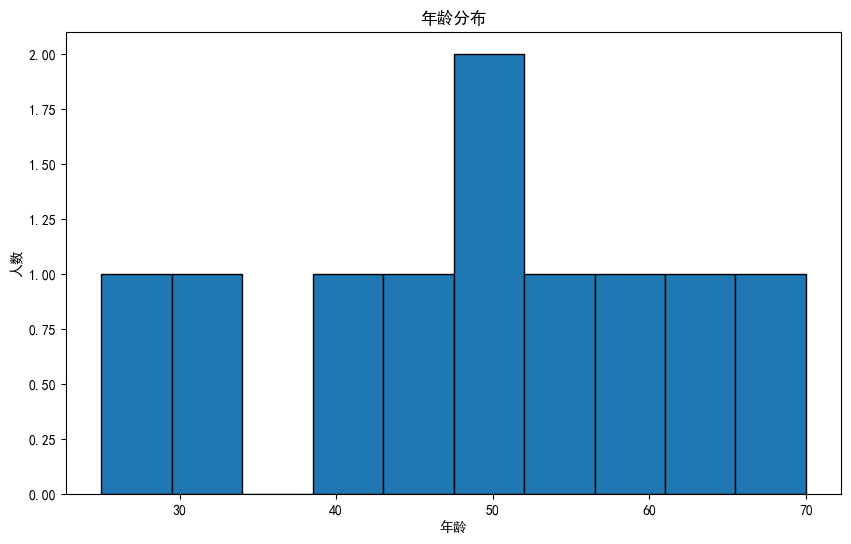

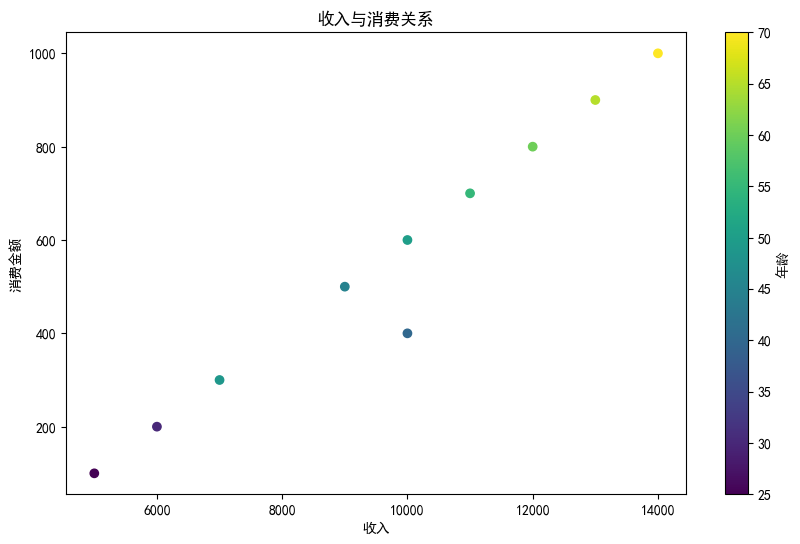

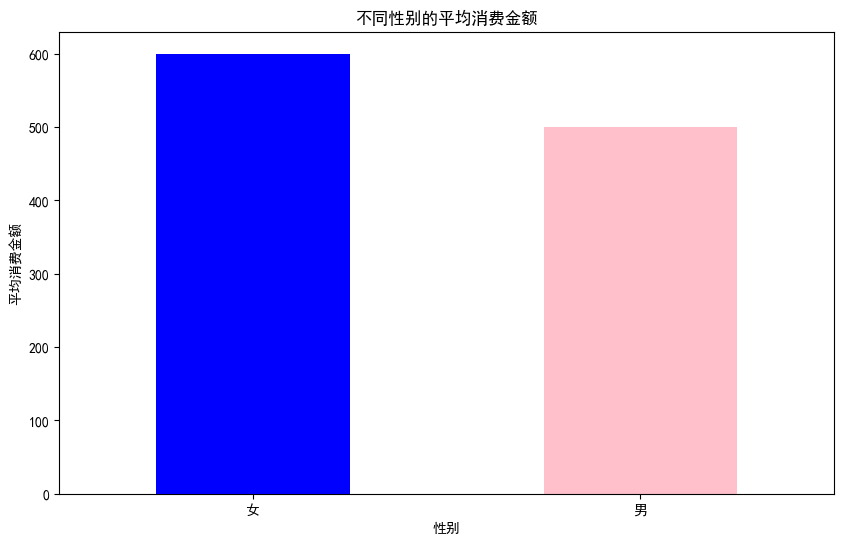

C:\Users\76470\AppData\Local\Temp\ipykernel_80028\3553760485.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  年龄组消费率 = 数据框.groupby('年龄组')['消费率'].mean()


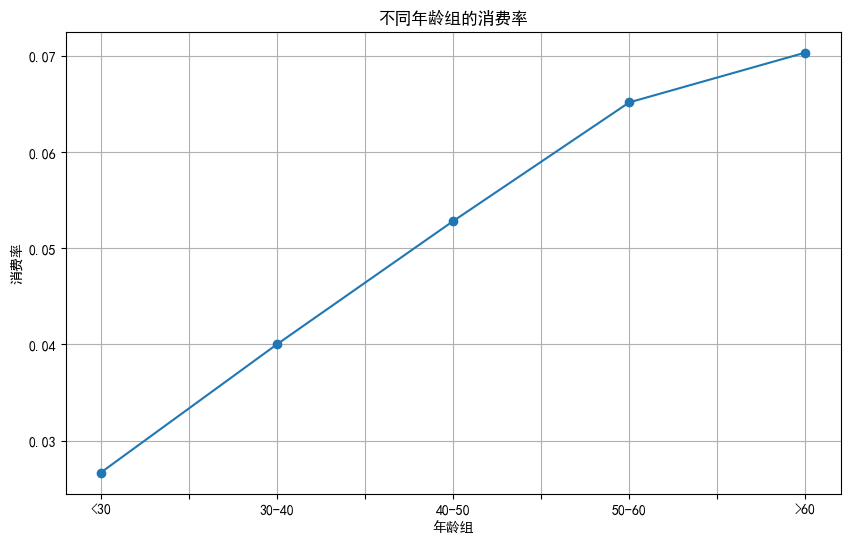

In [11]:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 1. 年龄分布
plt.figure(figsize=(10, 6))
plt.hist(数据框['年龄'], bins=10, edgecolor='black')
plt.title('年龄分布')
plt.xlabel('年龄')
plt.ylabel('人数')
plt.show()

# 2. 收入与消费关系
plt.figure(figsize=(10, 6))
plt.scatter(数据框['收入'], 数据框['消费金额'], c=数据框['年龄'], cmap='viridis')
plt.title('收入与消费关系')
plt.xlabel('收入')
plt.ylabel('消费金额')
plt.colorbar(label='年龄')
plt.show()

# 3. 不同性别的消费情况
性别消费 = 数据框.groupby('性别')['消费金额'].mean()
plt.figure(figsize=(10, 6))
性别消费.plot(kind='bar', color=['blue', 'pink'])
plt.title('不同性别的平均消费金额')
plt.xlabel('性别')
plt.ylabel('平均消费金额')
plt.xticks(rotation=0)
plt.show()

# 4. 不同年龄组的消费率
年龄组消费率 = 数据框.groupby('年龄组')['消费率'].mean()
plt.figure(figsize=(10, 6))
年龄组消费率.plot(kind='line', marker='o')
plt.title('不同年龄组的消费率')
plt.xlabel('年龄组')
plt.ylabel('消费率')
plt.grid(True)
plt.show()

## 8. 数据导出

将处理后的数据导出为 CSV 或其他格式，供后续使用。

In [12]:
# 导出为 CSV 文件
数据框.to_csv('处理后的数据.csv', index=False)

# 导出为 Excel 文件
# 数据框.to_excel('处理后的数据.xlsx', index=False)

# 导出为 JSON 文件
# 数据框.to_json('处理后的数据.json')

print('数据导出完成！')

数据导出完成！


## 9. 社招实战练习

模拟社招实战场景：处理一份电商用户行为数据。

In [ ]:
# 创建模拟电商用户行为数据
电商数据 = {
    '用户ID': range(1, 1001),
    '会话ID': [f'sess_{i}' for i in range(1, 1001)],
    '页面浏览量': np.random.randint(1, 20, 1000),
    '网站停留时间': np.random.randint(10, 300, 1000),
    '跳出率': np.random.uniform(0, 1, 1000),
    '是否购买': np.random.choice([0, 1], 1000, p=[0.7, 0.3]),
    '购买金额': np.where(np.random.choice([0, 1], 1000, p=[0.7, 0.3]) == 1,
                               np.random.uniform(10, 1000, 1000), 0),
    '设备类型': np.random.choice(['手机', '桌面', '平板'], 1000),
    '日期': pd.date_range('2024-01-01', periods=1000, freq='H')
}

电商数据框 = pd.DataFrame(电商数据)
print('电商用户行为数据：')
电商数据框.head()

# 练习：
# 1. 计算每个用户的平均页面浏览量
# 2. 计算不同设备的转化率（购买率）
# 3. 分析购买用户与非购买用户的行为差异
# 4. 提取消费频次、客单价等核心特征

# 1. 每个用户的平均页面浏览量
print('\n1. 每个用户的平均页面浏览量：')
用户页面浏览量 = 电商数据框.groupby('用户ID')['页面浏览量'].mean().reset_index()
用户页面浏览量.columns = ['用户ID', '平均页面浏览量']
用户页面浏览量.head()

# 2. 不同设备的转化率
print('\n2. 不同设备的转化率：')
设备转化率 = 电商数据框.groupby('设备类型').agg({
    '是否购买': 'mean',
    '购买金额': 'mean'
}).reset_index()
设备转化率.columns = ['设备类型', '转化率', '平均购买金额']
设备转化率

# 3. 购买用户与非购买用户的行为差异
print('\n3. 购买用户与非购买用户的行为差异：')
购买与非购买 = 电商数据框.groupby('是否购买').agg({
    '页面浏览量': 'mean',
    '网站停留时间': 'mean',
    '跳出率': 'mean'
}).reset_index()
购买与非购买['是否购买'] = 购买与非购买['是否购买'].map({0: '非购买用户', 1: '购买用户'})
购买与非购买

# 4. 提取核心特征
print('\n4. 用户核心特征：')
# 消费频次（每个用户的购买次数）
消费频次 = 电商数据框[电商数据框['是否购买'] == 1].groupby('用户ID').size().reset_index()
消费频次.columns = ['用户ID', '消费频次']

# 客单价（平均购买金额）
客单价 = 电商数据框[电商数据框['是否购买'] == 1].groupby('用户ID')['购买金额'].mean().reset_index()
客单价.columns = ['用户ID', '客单价']

# 合并特征
用户特征 = pd.merge(消费频次, 客单价, on='用户ID', how='outer')
用户特征 = 用户特征.fillna(0)
用户特征.head()

## 10. 高级操作

一些高级的 Pandas 操作，提升数据处理效率。

In [ ]:
# 创建示例数据
数据框1 = pd.DataFrame({
    'A': ['A0', 'A1', 'A2', 'A3'],
    'B': ['B0', 'B1', 'B2', 'B3'],
    'C': ['C0', 'C1', 'C2', 'C3'],
    'D': ['D0', 'D1', 'D2', 'D3']
}, index=[0, 1, 2, 3])

数据框2 = pd.DataFrame({
    'A': ['A4', 'A5', 'A6', 'A7'],
    'B': ['B4', 'B5', 'B6', 'B7'],
    'C': ['C4', 'C5', 'C6', 'C7'],
    'D': ['D4', 'D5', 'D6', 'D7']
}, index=[4, 5, 6, 7])

数据框3 = pd.DataFrame({
    'A': ['A8', 'A9', 'A10', 'A11'],
    'B': ['B8', 'B9', 'B10', 'B11'],
    'C': ['C8', 'C9', 'C10', 'C11'],
    'D': ['D8', 'D9', 'D10', 'D11']
}, index=[8, 9, 10, 11])

# 数据合并
print('数据合并：')
数据框列表 = [数据框1, 数据框2, 数据框3]
结果 = pd.concat(数据框列表)
结果

# 数据连接
print('\n数据连接：')
左表 = pd.DataFrame({
    '键': ['K0', 'K1', 'K2', 'K3'],
    'A': ['A0', 'A1', 'A2', 'A3'],
    'B': ['B0', 'B1', 'B2', 'B3']
})

右表 = pd.DataFrame({
    '键': ['K0', 'K1', 'K2', 'K3'],
    'C': ['C0', 'C1', 'C2', 'C3'],
    'D': ['D0', 'D1', 'D2', 'D3']
})

pd.merge(左表, 右表, on='键')

# 数据透视表
print('\n数据透视表：')
透视表 = 数据框.pivot_table(values='消费金额', index='性别', columns='年龄组', aggfunc='mean')
透视表

# 数据重塑
print('\n数据重塑：')
# 长格式转宽格式
宽格式数据 = 数据框.pivot(index='用户ID', columns='性别', values='消费金额')
宽格式数据.head()

## 总结

通过本 notebook，你已经学习了 Pandas 的核心操作，包括：

1. **数据读取与创建**：支持多种数据格式
2. **数据探索**：了解数据基本信息
3. **数据操作与转换**：
   - 条件操作 (if-then/if-then-else)
   - 数据分割 (Splitting)
   - 条件构建 (Building criteria)
   - 数据选择 (Selection)
4. **数据清洗**：处理缺失值和异常值
5. **特征工程**：创建新特征
6. **数据分组与聚合**：统计分析
7. **数据可视化**：直观展示数据
8. **数据导出**：保存处理后的数据
9. **社招实战**：模拟真实业务场景
10. **高级操作**：数据合并、连接、透视表等

这些技能是社招 AI 开发岗的基础要求，掌握后可以处理工业级数据，为后续的模型训练做准备。

本 notebook 涵盖了官方文档 cookbook 中的所有核心方法，按照人类认知逻辑进行组织，便于学习和参考。